In [1]:
import pandas as pd
import seaborn as srn
import numpy as np
from matplotlib import pyplot as plt

#analyse geral dos dados
dataset= pd.read_csv("StudentsPerformance.csv", sep=',')

print(dataset.head().to_string())

tamanho= dataset.shape
print(tamanho)

print(dataset.columns)



   gender race/ethnicity parental level of education         lunch test preparation course  math score  reading score  writing score
0  female        group B           bachelor's degree      standard                    none          72             72             74
1  female        group C                some college      standard               completed          69             90             88
2  female        group B             master's degree      standard                    none          90             95             93
3    male        group A          associate's degree  free/reduced                    none          47             57             44
4    male        group C                some college      standard                    none          76             78             75
(1000, 8)
Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='str')


In [2]:
dataset.columns = ['genero','raca/etnia','nivel da educacao familiar','almoco','curso de preparacao','nota em matematica','nota em leitura','nota em escrita']

In [3]:
#analisando agrupamento das colunas

agrupado_0=dataset["genero"].value_counts()
print(agrupado_0)
agrupado_1=dataset["raca/etnia"].value_counts()
print(agrupado_1)
agrupado_2=dataset["nivel da educacao familiar"].value_counts()
print(agrupado_2)
agrupado_3=dataset["almoco"].value_counts()
print(agrupado_3)
agrupado_4=dataset["curso de preparacao"].value_counts()
print(agrupado_4)
agrupado_5=dataset["nota em matematica"].value_counts()
print(agrupado_5)
agrupado_6=dataset["nota em leitura"].value_counts()
print(agrupado_6)
agrupado_7=dataset["nota em escrita"].value_counts()
print(agrupado_7)

genero
female    518
male      482
Name: count, dtype: int64
raca/etnia
group C    319
group D    262
group B    190
group E    140
group A     89
Name: count, dtype: int64
nivel da educacao familiar
some college          226
associate's degree    222
high school           196
some high school      179
bachelor's degree     118
master's degree        59
Name: count, dtype: int64
almoco
standard        645
free/reduced    355
Name: count, dtype: int64
curso de preparacao
none         642
completed    358
Name: count, dtype: int64
nota em matematica
65    36
62    35
69    32
59    32
73    27
      ..
24     1
26     1
19     1
23     1
8      1
Name: count, Length: 81, dtype: int64
nota em leitura
72    34
74    33
64    32
73    30
67    30
      ..
17     1
26     1
28     1
23     1
40     1
Name: count, Length: 72, dtype: int64
nota em escrita
74    35
70    33
68    31
73    28
80    27
      ..
19     1
35     1
15     1
30     1
23     1
Name: count, Length: 77, dtype: int64


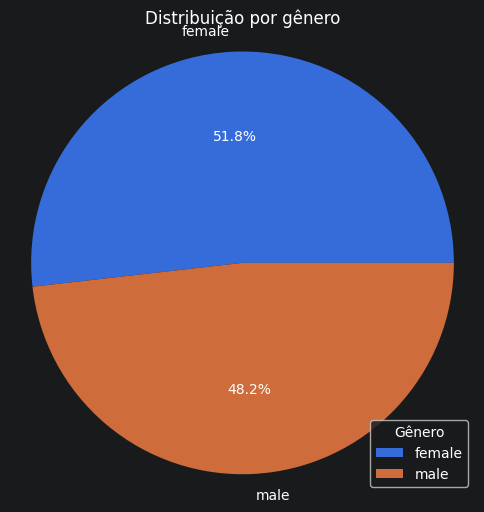

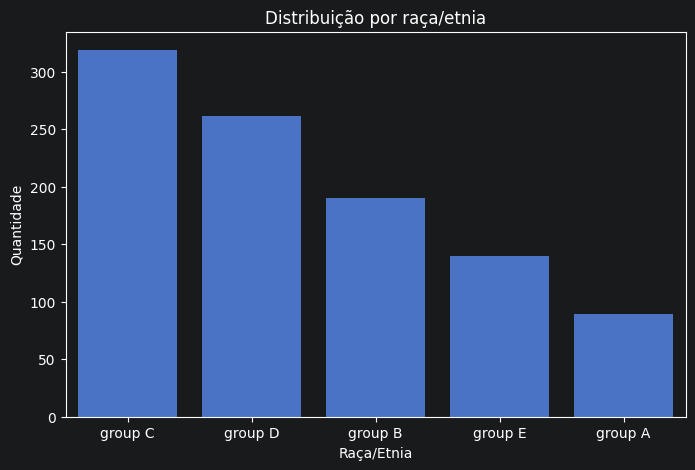

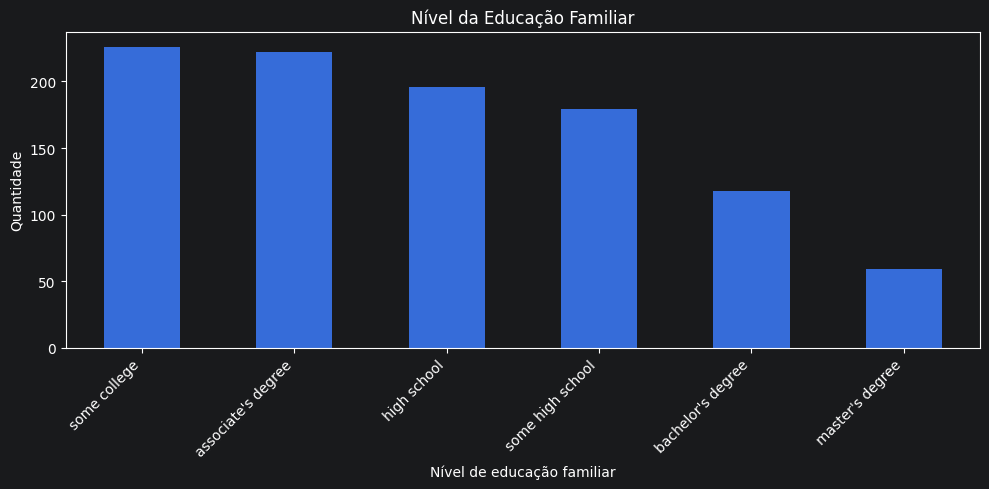

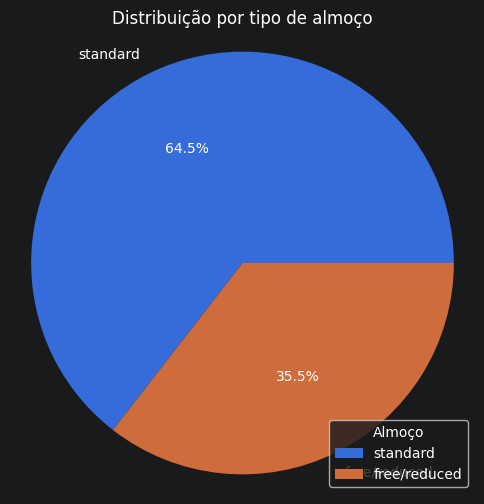

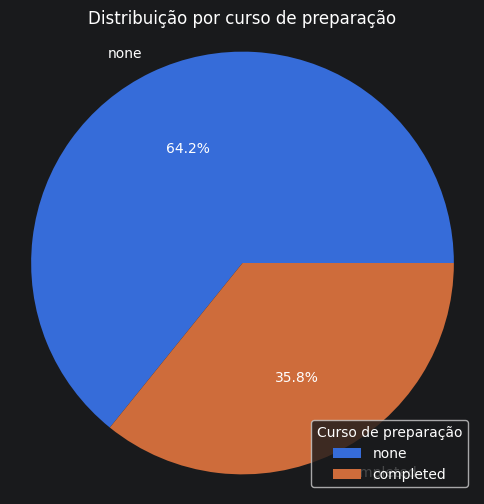

In [4]:
# Análise de gráficos

# Gênero
plt.figure(figsize=(6, 6))
plt.pie(
    agrupado_0,
    labels=agrupado_0.index,
    autopct='%1.1f%%'
)
plt.legend(title='Gênero', loc="lower right")
plt.title("Distribuição por gênero")
plt.axis('equal')
plt.show()


# Raça/Etnia
plt.figure(figsize=(8, 5))
srn.barplot(x=agrupado_1.index, y=agrupado_1.values)
plt.title("Distribuição por raça/etnia")
plt.xlabel("Raça/Etnia")
plt.ylabel("Quantidade")
plt.show()


# Nível de educação familiar
plt.figure(figsize=(10, 5))
agrupado_2.plot(kind="bar")
plt.title("Nível da Educação Familiar")
plt.xlabel("Nível de educação familiar")
plt.ylabel("Quantidade")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


# Almoço
plt.figure(figsize=(6, 6))
plt.pie(
    agrupado_3,
    labels=agrupado_3.index,
    autopct='%1.1f%%'
)
plt.legend(title='Almoço', loc="lower right")
plt.title("Distribuição por tipo de almoço")
plt.axis('equal')
plt.show()


# Curso de preparação
plt.figure(figsize=(6, 6))
plt.pie(
    agrupado_4,
    labels=agrupado_4.index,
    autopct='%1.1f%%'
)
plt.legend(title='Curso de preparação', loc="lower right")
plt.title("Distribuição por curso de preparação")
plt.axis('equal')
plt.show()


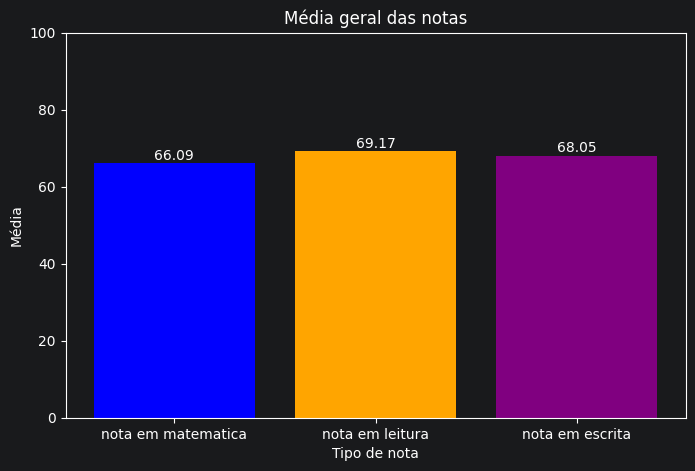

In [5]:
#analise das notas
dataset["media geral"] = (
    dataset["nota em matematica"] +
    dataset["nota em leitura"] +
    dataset["nota em escrita"]
) / 3
media_notas= dataset[["nota em matematica", "nota em leitura", "nota em escrita"]].mean()

#criando grafico de barras
plt.figure(figsize=(8,5))

plt.bar(media_notas.index,
        media_notas.values, color=["BLUE", "ORANGE", "PURPLE"]
        )
plt.title("Média geral das notas")
plt.xlabel("Tipo de nota")
plt.ylabel("Média")
plt.ylim(0,100)

#mostrando os valores em cima das barras
for i, valor in enumerate(media_notas.values):
    plt.text(i, valor +1, f"{valor:.2f}", ha="center")

plt.show()


In [6]:
# Verificando informações gerais do dataset
print(dataset.info())

# Verificando dados nulos
print(dataset.isnull().sum())

# Verificando dados duplicados
print("Quantidade de dados duplicados:", dataset.duplicated().sum())

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   genero                      1000 non-null   str    
 1   raca/etnia                  1000 non-null   str    
 2   nivel da educacao familiar  1000 non-null   str    
 3   almoco                      1000 non-null   str    
 4   curso de preparacao         1000 non-null   str    
 5   nota em matematica          1000 non-null   int64  
 6   nota em leitura             1000 non-null   int64  
 7   nota em escrita             1000 non-null   int64  
 8   media geral                 1000 non-null   float64
dtypes: float64(1), int64(3), str(5)
memory usage: 70.4 KB
None
genero                        0
raca/etnia                    0
nivel da educacao familiar    0
almoco                        0
curso de preparacao           0
nota em matematica            0
nota em leitura        

In [7]:
# Selecionando apenas as colunas de notas
colunas_notas = ["nota em matematica", "nota em leitura", "nota em escrita"]

notas = dataset[colunas_notas]

# Medidas estatísticas principais
print(notas.describe().to_string())

print("\nMédias:")
print(notas.mean())

print("\nMedianas:")
print(notas.median())

print("\nDesvio padrão:")
print(notas.std())

print("\nVariância:")
print(notas.var())

       nota em matematica  nota em leitura  nota em escrita
count          1000.00000      1000.000000      1000.000000
mean             66.08900        69.169000        68.054000
std              15.16308        14.600192        15.195657
min               0.00000        17.000000        10.000000
25%              57.00000        59.000000        57.750000
50%              66.00000        70.000000        69.000000
75%              77.00000        79.000000        79.000000
max             100.00000       100.000000       100.000000

Médias:
nota em matematica    66.089
nota em leitura       69.169
nota em escrita       68.054
dtype: float64

Medianas:
nota em matematica    66.0
nota em leitura       70.0
nota em escrita       69.0
dtype: float64

Desvio padrão:
nota em matematica    15.163080
nota em leitura       14.600192
nota em escrita       15.195657
dtype: float64

Variância:
nota em matematica    229.918998
nota em leitura       213.165605
nota em escrita       230.907992
dtyp

### Análise das medidas de centralidade e dispersão

As medidas de centralidade mostram o desempenho médio dos alunos em cada área avaliada, como Matemática, Leitura e Escrita.

O desvio padrão indica o quanto as notas variam em relação à média. Dessa forma, quanto maior for o desvio padrão, maior será a diferença de desempenho entre os alunos.

Portanto, essas medidas ajudam a entender não apenas qual foi o desempenho médio da turma, mas também se as notas ficaram concentradas próximas da média ou se houve grande variação entre os estudantes.

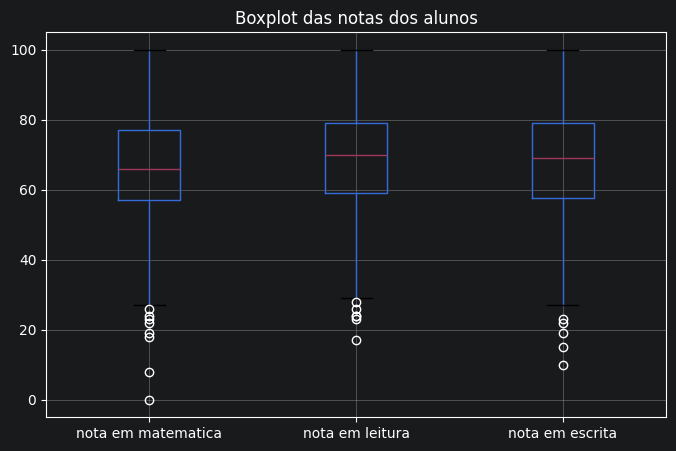

In [8]:
plt.figure(figsize=(8,5))
notas.boxplot()
plt.title("Boxplot das notas dos alunos")
plt.show()

### Análise do boxplot

O boxplot permite observar a mediana a variação das notas e possiveis outliers.

Caso existem outliers o dado precisa de uma analise refeita e entender o motivo desse ponto fora do padrão.


In [9]:
#Analise geral do box blot

q1 = dataset["media geral"].quantile(0.25)
q2 = dataset["media geral"].quantile(0.50)
q3 = dataset["media geral"].quantile(0.75)

iqr = q3 - q1
LS = q3 + 1.5 * iqr
LI = q1 - 1.5 * iqr

print(f"Q1: {q1:.2f}")
print(f"Mediana: {q2:.2f}")
print(f"Q3: {q3:.2f}")
print(f"Limite Superior: {LS:.2f}")
print(f"Limite Inferior: {LI:.2f}")

outliers = dataset[(dataset["media geral"] < LI) | (dataset["media geral"] > LS)]
print("Quantidade de outliers:", len(outliers))

Q1: 58.33
Mediana: 68.33
Q3: 77.67
Limite Superior: 106.67
Limite Inferior: 29.33
Quantidade de outliers: 6


                    nota em matematica  nota em leitura  nota em escrita
nota em matematica            1.000000         0.817580         0.802642
nota em leitura               0.817580         1.000000         0.954598
nota em escrita               0.802642         0.954598         1.000000


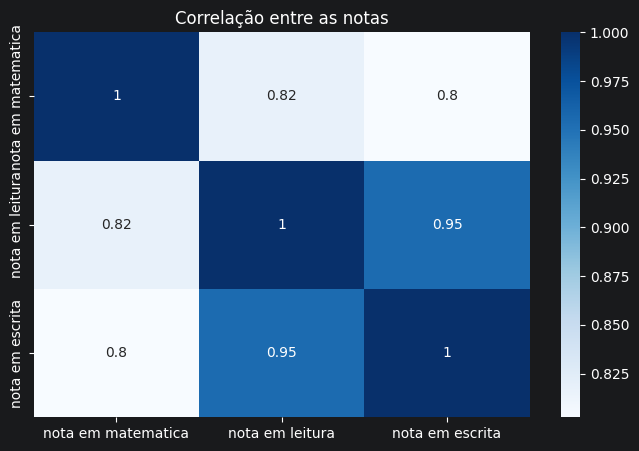

In [10]:
correlacao = notas.corr()

print(correlacao.to_string())

plt.figure(figsize=(8,5))
srn.heatmap(correlacao, annot=True, cmap="Blues")
plt.title("Correlação entre as notas")
plt.show()

In [11]:
def ans_grupo(coluna):
    resultado = dataset.groupby(coluna)[["nota em matematica", "nota em leitura", "nota em escrita"]].mean()

    print(f"Analise das médias por:{coluna}")
    print(resultado.to_string())
ans_grupo("genero")
ans_grupo("almoco")
ans_grupo("curso de preparacao")
ans_grupo("nivel da educacao familiar")

Analise das médias por:genero
        nota em matematica  nota em leitura  nota em escrita
genero                                                      
female           63.633205        72.608108        72.467181
male             68.728216        65.473029        63.311203
Analise das médias por:almoco
              nota em matematica  nota em leitura  nota em escrita
almoco                                                            
free/reduced           58.921127        64.653521        63.022535
standard               70.034109        71.654264        70.823256
Analise das médias por:curso de preparacao
                     nota em matematica  nota em leitura  nota em escrita
curso de preparacao                                                      
completed                     69.695531        73.893855        74.418994
none                          64.077882        66.534268        64.504673
Analise das médias por:nivel da educacao familiar
                            nota em mat

In [12]:
import scipy.stats as stats
import math

media = media_notas
desvio = media_notas.std()
n = len(dataset)

confianca = 0.95

erro_padrao = desvio / math.sqrt(n)

intervalo = stats.t.interval(
    confianca,
    df=n-1,
    loc=media,
    scale=erro_padrao
)

print("Média geral:", media)
print("Intervalo de confiança de 95% para a média geral:", intervalo)

Média geral: nota em matematica    66.089
nota em leitura       69.169
nota em escrita       68.054
dtype: float64
Intervalo de confiança de 95% para a média geral: (array([65.99223033, 69.07223033, 67.95723033]), array([66.18576967, 69.26576967, 68.15076967]))


In [13]:
grupo_completo = dataset[dataset["curso de preparacao"] == "completed"]["media geral"]
grupo_nao_completo = dataset[dataset["curso de preparacao"] == "none"]["media geral"]

t_stat, p_valor = stats.ttest_ind(grupo_completo, grupo_nao_completo)

print("Teste t de Student")
print("Estatística t:", t_stat)
print("p-valor:", p_valor)

if p_valor < 0.05:
    print("Resultado: rejeitamos H0. Existe diferença significativa entre os grupos.")
else:
    print("Resultado: não rejeitamos H0. Não há evidência de diferença significativa.")

Teste t de Student
Estatística t: 8.390944443482592
p-valor: 1.6337802035923472e-16
Resultado: rejeitamos H0. Existe diferença significativa entre os grupos.


In [14]:
grupos_educacao = [
    grupo["media geral"].values
    for nome, grupo in dataset.groupby("nivel da educacao familiar")
]

f_stat, p_valor_anova = stats.f_oneway(*grupos_educacao)

print("Teste ANOVA")
print("Estatística F:", f_stat)
print("p-valor:", p_valor_anova)

if p_valor_anova < 0.05:
    print("Resultado: rejeitamos H0. Existe diferença significativa entre pelo menos dois níveis de escolaridade.")
else:
    print("Resultado: não rejeitamos H0. Não há diferença significativa entre os grupos.")

Teste ANOVA
Estatística F: 10.75314696233657
p-valor: 4.3810464809409217e-10
Resultado: rejeitamos H0. Existe diferença significativa entre pelo menos dois níveis de escolaridade.


In [15]:
#relação etnia e notas
relacao_etnia_notas = dataset.groupby("raca/etnia")[colunas_notas + ["media geral"]].mean()
relacao_etnia_notas = relacao_etnia_notas.sort_values("media geral", ascending=False)

print("Relação entre raça/etnia e notas:")
print(relacao_etnia_notas.to_string())

Relação entre raça/etnia e notas:
            nota em matematica  nota em leitura  nota em escrita  media geral
raca/etnia                                                                   
group E              73.821429        73.028571        71.407143    72.752381
group D              67.362595        70.030534        70.145038    69.179389
group C              64.463950        69.103448        67.827586    67.131661
group B              63.452632        67.352632        65.600000    65.468421
group A              61.629213        64.674157        62.674157    62.992509


raca/etnia
group E    72.752381
group D    69.179389
group C    67.131661
group B    65.468421
group A    62.992509


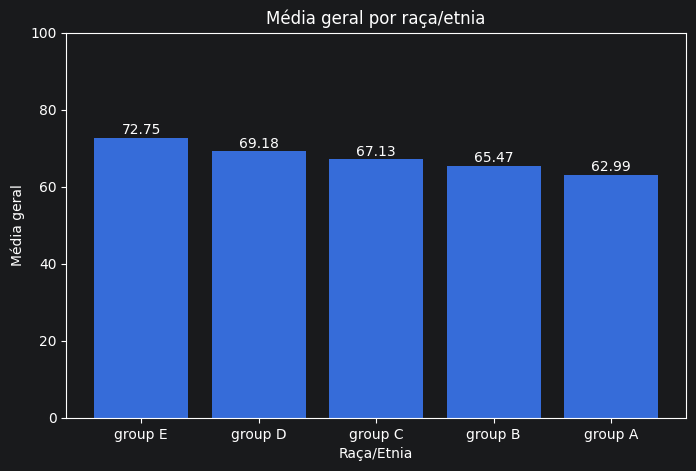

In [16]:
media_etnia = dataset.groupby("raca/etnia")["media geral"].mean().sort_values(ascending=False)

print(media_etnia.to_string())

plt.figure(figsize=(8, 5))
plt.bar(media_etnia.index, media_etnia.values)

plt.title("Média geral por raça/etnia")
plt.xlabel("Raça/Etnia")
plt.ylabel("Média geral")
plt.ylim(0, 100)

for i, valor in enumerate(media_etnia.values):
    plt.text(i, valor + 1, f"{valor:.2f}", ha="center")

plt.show()

# ANÁLISE FINAL DOS DADOS

## 1. Distribuição inicial dos alunos

### Distribuição por gênero

| Gênero | Quantidade |
| ------ | ---------: |
| Female |        518 |
| Male   |        482 |

### Distribuição por raça/etnia

| Raça/Etnia | Quantidade |
| ---------- | ---------: |
| Group C    |        319 |
| Group D    |        262 |
| Group B    |        190 |
| Group E    |        140 |
| Group A    |         89 |

### Distribuição por tipo de almoço

| Tipo de almoço | Quantidade |
| -------------- | ---------: |
| Standard       |        645 |
| Free/reduced   |        355 |

### Distribuição por curso de preparação

| Curso de preparação | Quantidade |
| ------------------- | ---------: |
| None                |        642 |
| Completed           |        358 |

---

## 2. Análise geral das notas

### Média das notas por disciplina

| Disciplina | Média |
| ---------- | ----: |
| Matemática | 66.09 |
| Leitura    | 69.17 |
| Escrita    | 68.05 |

A maior média foi em Leitura, seguida por Escrita.

---

## 3. Medidas de centralidade e dispersão da média geral

| Medida        | Valor |
| ------------- | ----: |
| Média geral   | 67.77 |
| Mediana       | 68.33 |
| Desvio padrão | 14.26 |

A média geral dos alunos foi de aproximadamente 67.77. Como a média e a mediana estão próximas, os dados não apresentam uma diferença muito grande entre o centro da distribuição e o valor médio.

---

## 4. Análise dos quartis e limites para outliers

| Medida          |  Valor |
| --------------- | -----: |
| Q1              |  58.33 |
| Mediana         |  68.33 |
| Q3              |  77.67 |
| Limite inferior |  29.33 |
| Limite superior | 106.67 |

Os limites calculados indicam que valores abaixo de 29.33 podem ser considerados possíveis outliers inferiores.

### Menor resultado encontrado

| Disciplina  | Nota |
| ----------- | ---: |
| Matemática  |    0 |
| Leitura     |   17 |
| Escrita     |   10 |
| Média geral | 9.00 |

Esse resultado representa um caso de desempenho extremamente baixo em comparação com o restante dos alunos.

---

## 5. Correlação entre as notas

| Relação              | Correlação |
| -------------------- | ---------: |
| Matemática x Leitura |       0.82 |
| Matemática x Escrita |       0.80 |
| Leitura x Escrita    |       0.95 |

As correlações entre as notas são positivas e fortes. A maior correlação ocorreu entre Leitura e Escrita, com valor de 0.95.

---

## 6. Desempenho por gênero

### Grupo Female

| Disciplina  | Média |
| ----------- | ----: |
| Matemática  | 63.63 |
| Leitura     | 72.61 |
| Escrita     | 72.47 |
| Média geral | 69.57 |

### Grupo Male

| Disciplina  | Média |
| ----------- | ----: |
| Matemática  | 68.73 |
| Leitura     | 65.47 |
| Escrita     | 63.31 |
| Média geral | 65.84 |

O grupo male apresentou média maior em Matemática. Já o grupo female apresentou médias maiores em Leitura, Escrita e também na média geral.

---

## 7. Desempenho por curso de preparação

| Curso de preparação | Média geral |
| ------------------- | ----------: |
| Completed           |       72.67 |
| None                |       65.04 |

Os alunos que completaram o curso de preparação apresentaram média geral superior aos alunos que não fizeram o curso.

---

## 8. Desempenho por nível de educação familiar

| Nível de educação familiar | Média geral |
| -------------------------- | ----------: |
| Master's degree            |       73.60 |
| Bachelor's degree          |       71.92 |
| Associate's degree         |       69.57 |
| Some college               |       68.48 |
| Some high school           |       65.11 |
| High school                |       63.10 |

Os alunos cujos responsáveis possuem maior nível de escolaridade apresentaram médias gerais mais altas.

---

## 9. Desempenho por raça/etnia

| Raça/Etnia | Média geral |
| ---------- | ----------: |
| Group E    |       72.75 |
| Group D    |       69.18 |
| Group C    |       67.13 |
| Group B    |       65.47 |
| Group A    |       62.99 |

---

## 10. Conclusão geral

A análise dos dados mostrou que os alunos tiveram melhor desempenho médio em Leitura e Escrita, enquanto Matemática apresentou a menor média. A média geral da turma foi de aproximadamente 67.77, com uma mediana próxima, indicando que o desempenho central dos alunos está em torno desse valor.

A correlação entre as notas foi positiva e forte, principalmente entre Leitura e Escrita. Isso mostra que os alunos que apresentam bom desempenho em uma área tendem também a apresentar bom desempenho em outras.

As comparações por grupos indicaram alguns padrões importantes. Alunos que completaram o curso de preparação tiveram média geral maior do que aqueles que não completaram. Além disso, alunos com maior nível de educação familiar também apresentaram médias mais altas.

A análise por gênero mostrou que o grupo male teve melhor desempenho em Matemática, enquanto o grupo female apresentou melhores médias em Leitura, Escrita e na média geral. Já a análise por raça/etnia mostrou diferenças entre os grupos, com maior média no group E e menor média no group A.

Portanto, os principais fatores associados a um melhor desempenho neste dataset foram a realização do curso de preparação, maior nível de educação familiar e, possivelmente, melhores condições relacionadas ao tipo de almoço. Essas análises ajudam a compreender padrões no desempenho dos alunos, mas devem ser interpretadas como associações estatísticas, e não como causas definitivas.
